In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

In [3]:
np.random.seed(42)
n_samples = 2000

time_index = np.arange(n_samples)

# realistic CPU pattern — daily cycle + noise
cpu_base  = 35 + 10 * np.sin(time_index / 100)
cpu_trend = 0.003 * time_index                    # slight upward trend
cpu_noise = np.random.normal(0, 4, n_samples)
cpu       = np.clip(cpu_base + cpu_trend + cpu_noise, 0, 100)

# realistic RAM pattern
ram_base  = 55 + 8 * np.sin(time_index / 150 + 1)
ram_noise = np.random.normal(0, 3, n_samples)
ram       = np.clip(ram_base + ram_noise, 0, 100)

df = pd.DataFrame({
    'cpu_percent': cpu,
    'ram_percent': ram,
    'timestamp':   time_index,
})

print(f"Dataset shape: {df.shape}")
print(df.describe().round(2))

Dataset shape: (2000, 3)
       cpu_percent  ram_percent  timestamp
count      2000.00      2000.00    2000.00
mean         38.47        55.42     999.50
std           8.06         6.40     577.49
min          16.72        38.57       0.00
25%          32.33        50.25     499.75
50%          38.50        55.67     999.50
75%          44.81        60.79    1499.25
max          60.02        72.43    1999.00


In [5]:
def create_features(series, window=10, horizon=6):
    """
    window  = how many past readings to use as input
    horizon = how many steps ahead to predict
              (6 steps × 5 seconds = 30 seconds ahead)

    Each row:
      X = [t-9, t-8, t-7, ..., t-0]  (last 10 readings)
      y = value at t+horizon
    """
    X, y = [], []
    for i in range(window, len(series) - horizon):
        X.append(series[i - window:i])
        y.append(series[i + horizon])
    return np.array(X), np.array(y)

WINDOW  = 10   # use last 10 readings (50 seconds of data)
HORIZON = 6    # predict 6 steps ahead (30 seconds into future)

X_cpu, y_cpu = create_features(df['cpu_percent'].values, WINDOW, HORIZON)
X_ram, y_ram = create_features(df['ram_percent'].values, WINDOW, HORIZON)

print(f"CPU — X shape: {X_cpu.shape}, y shape: {y_cpu.shape}")
print(f"RAM — X shape: {X_ram.shape}, y shape: {y_ram.shape}")
print(f"\nExample:")
print(f"  Input  (last 10 readings): {X_cpu[0].round(1)}")
print(f"  Target (30s later)       : {y_cpu[0]:.1f}%")

CPU — X shape: (1984, 10), y shape: (1984,)
RAM — X shape: (1984, 10), y shape: (1984,)

Example:
  Input  (last 10 readings): [37.  34.5 37.8 41.4 34.5 34.6 41.9 38.8 33.9 38.1]
  Target (30s later)       : 32.6%


In [7]:
# split into train/test — 80% train, 20% test
X_cpu_train, X_cpu_test, y_cpu_train, y_cpu_test = train_test_split(
    X_cpu, y_cpu, test_size=0.2, random_state=42, shuffle=False
)
X_ram_train, X_ram_test, y_ram_train, y_ram_test = train_test_split(
    X_ram, y_ram, test_size=0.2, random_state=42, shuffle=False
)

# scale features
scaler_cpu = StandardScaler()
scaler_ram = StandardScaler()

X_cpu_train_s = scaler_cpu.fit_transform(X_cpu_train)
X_cpu_test_s  = scaler_cpu.transform(X_cpu_test)

X_ram_train_s = scaler_ram.fit_transform(X_ram_train)
X_ram_test_s  = scaler_ram.transform(X_ram_test)

# train linear regression models
model_cpu = LinearRegression()
model_ram = LinearRegression()

model_cpu.fit(X_cpu_train_s, y_cpu_train)
model_ram.fit(X_ram_train_s, y_ram_train)

print("Models trained successfully")
print(f"Training samples — CPU: {len(X_cpu_train)}, RAM: {len(X_ram_train)}")

Models trained successfully
Training samples — CPU: 1587, RAM: 1587


In [9]:
# predictions on test set
cpu_preds = model_cpu.predict(X_cpu_test_s)
ram_preds = model_ram.predict(X_ram_test_s)

# clip predictions to valid range
cpu_preds = np.clip(cpu_preds, 0, 100)
ram_preds = np.clip(ram_preds, 0, 100)

# metrics
cpu_mae = mean_absolute_error(y_cpu_test, cpu_preds)
ram_mae = mean_absolute_error(y_ram_test, ram_preds)
cpu_r2  = r2_score(y_cpu_test, cpu_preds)
ram_r2  = r2_score(y_ram_test, ram_preds)

print("=" * 40)
print("Model Evaluation Results")
print("=" * 40)
print(f"CPU  →  MAE: {cpu_mae:.2f}%   R²: {cpu_r2:.3f}")
print(f"RAM  →  MAE: {ram_mae:.2f}%   R²: {ram_r2:.3f}")
print()
print("What this means:")
print(f"  CPU predictions are off by ~{cpu_mae:.1f}% on average")
print(f"  RAM predictions are off by ~{ram_mae:.1f}% on average")
print(f"  R²=1.0 is perfect, R²=0.0 means the model learned nothing")

Model Evaluation Results
CPU  →  MAE: 3.26%   R²: 0.696
RAM  →  MAE: 2.50%   R²: 0.680

What this means:
  CPU predictions are off by ~3.3% on average
  RAM predictions are off by ~2.5% on average
  R²=1.0 is perfect, R²=0.0 means the model learned nothing


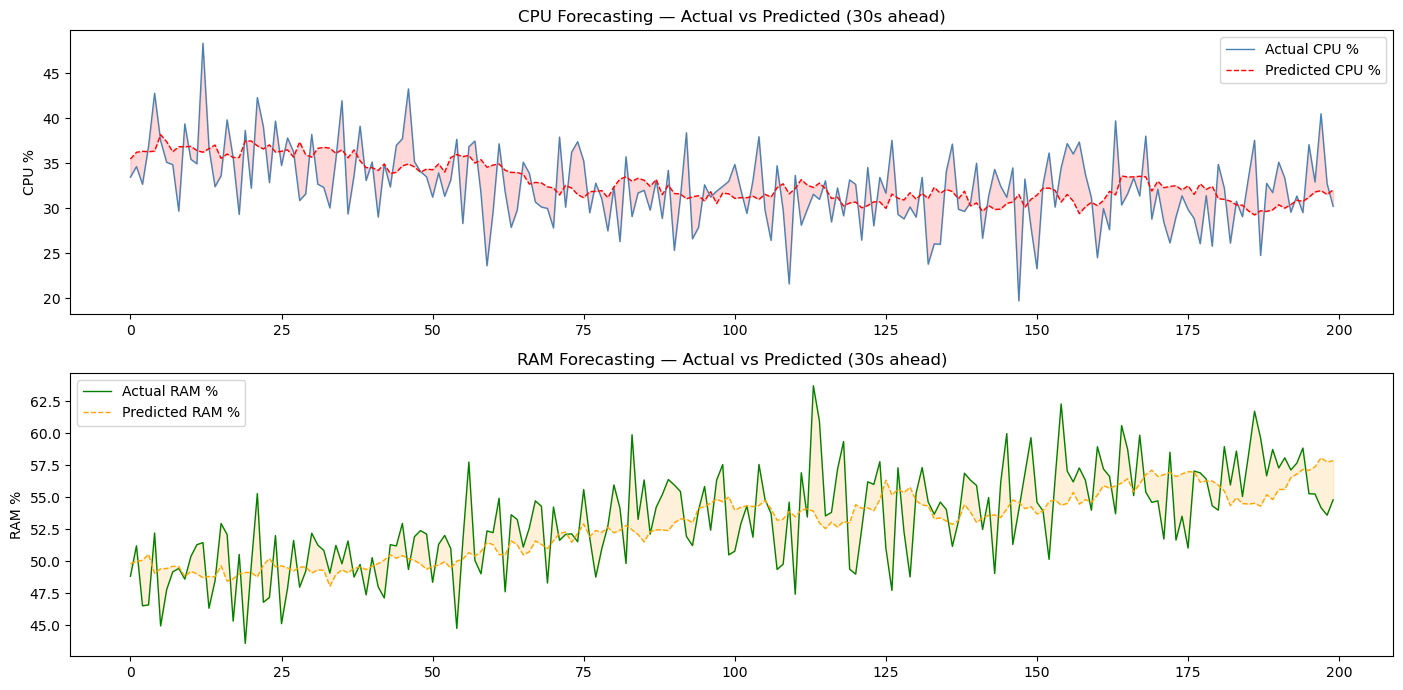

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

n_show = 200  # show first 200 test samples

axes[0].plot(y_cpu_test[:n_show],   color='steelblue', linewidth=1,
             label='Actual CPU %')
axes[0].plot(cpu_preds[:n_show],    color='red',       linewidth=1,
             linestyle='--', label='Predicted CPU %')
axes[0].fill_between(range(n_show), cpu_preds[:n_show],
                     y_cpu_test[:n_show], alpha=0.15, color='red')
axes[0].set_title('CPU Forecasting — Actual vs Predicted (30s ahead)')
axes[0].set_ylabel('CPU %')
axes[0].legend()

axes[1].plot(y_ram_test[:n_show],   color='green', linewidth=1,
             label='Actual RAM %')
axes[1].plot(ram_preds[:n_show],    color='orange', linewidth=1,
             linestyle='--', label='Predicted RAM %')
axes[1].fill_between(range(n_show), ram_preds[:n_show],
                     y_ram_test[:n_show], alpha=0.15, color='orange')
axes[1].set_title('RAM Forecasting — Actual vs Predicted (30s ahead)')
axes[1].set_ylabel('RAM %')
axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
def predict_next(metric, last_10_values):
    """
    Simulate what Django will call.
    metric         : 'cpu' or 'ram'
    last_10_values : list of last 10 readings
    Returns predicted value 30 seconds from now.
    """
    x = np.array(last_10_values).reshape(1, -1)

    if metric == 'cpu':
        x_scaled = scaler_cpu.transform(x)
        pred     = model_cpu.predict(x_scaled)[0]
    else:
        x_scaled = scaler_ram.transform(x)
        pred     = model_ram.predict(x_scaled)[0]

    return round(float(np.clip(pred, 0, 100)), 1)


# simulate Django sending last 10 CPU readings
normal_cpu  = [33, 35, 34, 36, 38, 37, 35, 36, 34, 35]
rising_cpu  = [40, 45, 52, 58, 63, 68, 72, 76, 80, 85]
normal_ram  = [54, 56, 55, 57, 56, 58, 55, 57, 56, 55]

print("Single prediction tests:")
print("-" * 45)
print(f"Normal CPU  {normal_cpu[-3:]}... → predicted in 30s: {predict_next('cpu', normal_cpu)}%")
print(f"Rising CPU  {rising_cpu[-3:]}... → predicted in 30s: {predict_next('cpu', rising_cpu)}%")
print(f"Normal RAM  {normal_ram[-3:]}... → predicted in 30s: {predict_next('ram', normal_ram)}%")

Single prediction tests:
---------------------------------------------
Normal CPU  [36, 34, 35]... → predicted in 30s: 35.5%
Rising CPU  [76, 80, 85]... → predicted in 30s: 64.3%
Normal RAM  [57, 56, 55]... → predicted in 30s: 55.8%


In [15]:
os.makedirs('models', exist_ok=True)

# save models
joblib.dump(model_cpu,   'models/forecasting_cpu_model.pkl')
joblib.dump(model_ram,   'models/forecasting_ram_model.pkl')

# save scalers — IMPORTANT: must use same scaler in Django
joblib.dump(scaler_cpu,  'models/forecasting_cpu_scaler.pkl')
joblib.dump(scaler_ram,  'models/forecasting_ram_scaler.pkl')

print("Saved:")
print("  models/forecasting_cpu_model.pkl")
print("  models/forecasting_ram_model.pkl")
print("  models/forecasting_cpu_scaler.pkl")
print("  models/forecasting_ram_scaler.pkl")

# verify
loaded_model  = joblib.load('models/forecasting_cpu_model.pkl')
loaded_scaler = joblib.load('models/forecasting_cpu_scaler.pkl')
test_input    = np.array([40, 45, 52, 58, 63, 68, 72, 76, 80, 85]).reshape(1, -1)
test_pred     = loaded_model.predict(loaded_scaler.transform(test_input))[0]
print(f"\nVerification — rising CPU prediction: {test_pred:.1f}%")
print("All models saved and verified successfully")

Saved:
  models/forecasting_cpu_model.pkl
  models/forecasting_ram_model.pkl
  models/forecasting_cpu_scaler.pkl
  models/forecasting_ram_scaler.pkl

Verification — rising CPU prediction: 64.3%
All models saved and verified successfully
